# Python Notebook for training the Two-Tower System

**PFG Mario Hervás Núñez - "Development of a personalized recommender system based on personal Letterboxd profiles"**

This notebook is used for implementing and training the Two-Tower System. It loads both movies.csv and interactions.csv, build the PyTorch models alongside the datasets and trains them. Finally, generates a .pt file that has the model to make the first recommendatios.

In [ ]:
#Cell for all the imports and establishing reproducibility

import os
import json
import random
import zipfile
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Paths
MOVIES_CSV = "/content/movies.csv"
INTERACTIONS_CSV = "/content/interactions.csv"
CHECKPOINT_PATH = "/content/checkpoint.pt"

In [ ]:
# Hyperparameters

EMBEDDING_DIM = 128
HIDDEN_DIM = 256
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
N_EPOCHS = 100
PATIENCE = 15
VAL_SPLIT = 0.2
POSITIVE_THRESHOLD = 0.6
TOP_K = 10
MIN_POSITIVES_PER_USER = 5

## First step - Loading and Preprocessing of the CSV

1. Load both files from the path and cross them with the title.
2. Clean NaN inside the dataset



In [ ]:


movies = pd.read_csv(MOVIES_CSV)
interactions = pd.read_csv(INTERACTIONS_CSV)

for clean in ["tmdb_genres","nanogenres","themes"]:
  movies[clean] = movies[clean].fillna("")



interactions["title_normalized"] = interactions["Name"].str.lower()
interactions = interactions.dropna(subset=["title_normalized","Rating","username"])


In [ ]:

print(f"Unique users: {interactions['username'].nunique()}")
print(f'Total movies with at least one single rating: {interactions['title_normalized'].nunique()}')

Unique users: 20
Total movies with at least one single rating: 3988


## Second step - Defining vocabularies and indexes

Conversion from Strings to numbers. Arraging themes, genre and nanogenre as a vector.

In [ ]:
unique_users = sorted(interactions["username"].unique())
user2id = {u: i for i, u in enumerate(unique_users)}
id2user = {i: u for u, i in user2id.items()}
n_users = len(user2id)

unique_movies = sorted(movies["title_normalized"].unique())
movie2id = {m:i for i, m in enumerate(unique_movies)}
id2movie = {i: m for m, i in movie2id.items()}
n_movies = len(movie2id)

#Taking out the | in generes and nanogenres
def split_pipe(s):
  if not isinstance(s, str) or s.strip() == "":
      return []
  return [x.strip() for x in s.split("|") if x.strip()]

all_genres = set()
for g in movies["tmdb_genres"]:
  all_genres.update(split_pipe(g))
genre_vocab = sorted(all_genres)
genre2id = {g: i for i, g in enumerate(genre_vocab)}

nanogenre_counts = Counter()
for s in movies["nanogenres"]:
    for ng in split_pipe(s):
        nanogenre_counts[ng] += 1

MIN_NANOGENRE_FREQ = 5
nanogenre_vocab = sorted(ng for ng, count in nanogenre_counts.items()
                         if count >= MIN_NANOGENRE_FREQ)
nanogenre2idx = {n: i for i, n in enumerate(nanogenre_vocab)}

themes = sorted(movies["themes"].unique())
theme2id = {t: i for i, t in enumerate(themes)}
n_themes = len(theme2id)

feature_dim = len(genre_vocab)+len(nanogenre_vocab)+n_themes

## Third Step - Movie Feauture Encoding

The following cell creates the tensors that will be used. It uses a function that returns a NumPy array, with genres, nano and themes together.


In [ ]:

def encode_movie_features(row):
  g_vec = np.zeros(len(genre_vocab),dtype=np.float32)
  for g in split_pipe(row["tmdb_genres"]):
    if g in genre2id:
      g_vec[genre2id[g]] = 1.0
  n_vec = np.zeros(len(nanogenre_vocab),dtype=np.float32)
  for n in split_pipe(row["nanogenres"]):
    if n in nanogenre2idx:
      n_vec[nanogenre2idx[n]] = 1.0
  t_vec=np.zeros(n_themes,dtype=np.float32)
  if row["themes"] in theme2id:
    t_vec[theme2id[row["themes"]]] = 1.0
  return np.concatenate([g_vec,n_vec,t_vec])

movie_features_list = []
for movie_id in range(n_movies):
  title = id2movie[movie_id]
  row = movies[movies["title_normalized"] == title].iloc[0]#usar iloc para operación índice en df
  movie_features_list.append(encode_movie_features(row))

movie_features_tensor = torch.tensor(np.stack(movie_features_list), dtype=torch.float32)
movie_feature_dim = movie_features_tensor.shape[1]

print(movie_features_tensor)


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.]])


## Fourth Step - Creating PyTorch Dataset

'positives': thos interactions where rating is greater that POSITIVE_THRESHOLD
´seen_by_user´: all of the seen movies by user, negative sampling

Temporal Split and Dataset Objects

In [ ]:
positives = interactions[interactions["Rating"] > POSITIVE_THRESHOLD].copy()
positives["user_id"] = positives["username"].map(user2id)
positives["movie_id"] = positives["title_normalized"].map(movie2id)
positives = positives[["user_id","movie_id","Rating","Date"]].dropna()
positives["user_id"] = positives["user_id"].astype(int)
positives["movie_id"] = positives["movie_id"].astype(int)


In [ ]:
print(f"Number of positive interactions (rating > {POSITIVE_THRESHOLD}): {len(positives)}")

Number of positive interactions (rating > 0.6): 5720


In [ ]:
seen_by_user = defaultdict(set)
for _, row in interactions.iterrows():
  u_id = user2id.get(row["username"])
  m_id = movie2id.get(row["title_normalized"])
  if u_id is not None and m_id is not None:
    seen_by_user[u_id].add(m_id)


In [ ]:
train_pairs = []
val_pairs = []
for u_id in range(n_users):
  user_pos = positives[positives["user_id"] == u_id].sort_values("Date")
  n_total = len(user_pos)
  if n_total < MIN_POSITIVES_PER_USER:
    for _, row in user_pos.iterrows():
      train_pairs.append([u_id, row["movie_id"]])
    continue
  n_val = max(1,int(n_total*VAL_SPLIT))
  n_train = n_total-n_val
  for i, (_,row) in enumerate(user_pos.iterrows()):
    pair = [u_id,int(row["movie_id"])]
    if i < n_train:
      train_pairs.append(pair)
    else:
      val_pairs.append(pair)

In [ ]:
print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs:   {len(val_pairs)}")
print(f"Users with Val set: {len(set(p[0] for p in val_pairs))}/{n_users}")

Train pairs: 4584
Val pairs:   1136
Users with Val set: 20/20


In [ ]:
class BPRDataset(Dataset):
  def __init__(self,pairs,seen_by_user,n_movies):
    self.pairs = pairs
    self.seen_by_user = seen_by_user
    self.n_movies = n_movies
  def __len__(self):
    return len(self.pairs)

  def __getitem__(self,idx):
    user_id, movie_pos = self.pairs[idx]
    seen = self.seen_by_user[user_id]
    found = False
    while not found:
      movie_neg = random.randint(0, self.n_movies -1)
      if movie_neg not in seen:
        found = True
    return user_id, movie_pos, movie_neg

train_dataset = BPRDataset(train_pairs, seen_by_user,n_movies)
val_dataset = BPRDataset(val_pairs, seen_by_user,n_movies)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=0)


In [ ]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 18
Val batches: 5


## Fifth Step - Defining Two-Tower Model in Pytorch

In [ ]:
class TwoTowerModel(nn.Module):
  def __init__(self, n_users,movie_feature_dim,embedding_dim=EMBEDDING_DIM,hidden_dim=HIDDEN_DIM):
    super().__init__()
    self.user_embedding = nn.Embedding(n_users,embedding_dim)
    self.movie_tower = nn.Sequential(
        nn.Linear(movie_feature_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, embedding_dim)
    )
    nn.init.normal_(self.user_embedding.weight, std=0.01)
  def encode_user(self, user_ids):
    return self.user_embedding(user_ids)
  def encode_movie(self, movie_features):
    return self.movie_tower(movie_features)
  def forward(self,user_ids,movie_features_pos,movie_features_neg):
    u = self.encode_user(user_ids)
    mp = self.encode_movie(movie_features_pos)
    mn = self.encode_movie(movie_features_neg)
    score_pos = (u * mp).sum(dim=1)
    score_neg = (u * mn).sum(dim=1)
    return score_pos, score_neg

In [ ]:
model = TwoTowerModel(n_users, movie_feature_dim, EMBEDDING_DIM, HIDDEN_DIM).to(device)
print(model)

TwoTowerModel(
  (user_embedding): Embedding(20, 128)
  (movie_tower): Sequential(
    (0): Linear(in_features=1993, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
)


## Sixth Step - Training Loop

In [ ]:
def bpr_loss(score_pos, score_neg):
  return -F.logsigmoid(score_pos - score_neg).mean()

optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
movie_features_tensor_dev = movie_features_tensor.to(device)

# Precompute val_pos_by_user once (it doesn't change between epochs)
val_pos_by_user = defaultdict(set)
for u, m in val_pairs:
    val_pos_by_user[u].add(m)

def evaluate_precision_recall_at_k():
  model.eval()
  with torch.no_grad():
      all_movie_embeddings = model.encode_movie(movie_features_tensor_dev)
      precisions = []
      recalls = []
      for u_id in range(n_users):
          if not val_pos_by_user[u_id]:
              continue
          u_emb = model.encode_user(torch.tensor([u_id], device=device))
          scores = (u_emb * all_movie_embeddings).sum(dim=1)
          excluded = seen_by_user[u_id] - val_pos_by_user[u_id]
          if excluded:
              scores[list(excluded)] = -1e9
          topk = torch.topk(scores, k=TOP_K).indices.cpu().tolist()
          relevant = val_pos_by_user[u_id]
          hits = len(set(topk) & relevant)
          precisions.append(hits / TOP_K)
          recalls.append(hits / len(relevant))
  return (sum(precisions) / len(precisions) if precisions else 0.0,
          sum(recalls) / len(recalls) if recalls else 0.0)

train_losses = []
val_losses = []
precisions_at_k = []
recalls_at_k = []

best_precision = -1.0
best_state = None
best_epoch = 0
epochs_no_improve = 0

for epoch in range(1, N_EPOCHS+1):
  model.train()
  epoch_loss = 0.0
  n_batches = 0
  for user_ids, movie_pos, movie_neg in train_loader:
    user_ids = user_ids.to(device)
    feat_pos = movie_features_tensor_dev[movie_pos]
    feat_neg = movie_features_tensor_dev[movie_neg]

    optimizer.zero_grad()
    score_pos, score_neg = model(user_ids, feat_pos, feat_neg)
    loss = bpr_loss(score_pos,score_neg)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    n_batches += 1

  avg_train = epoch_loss / max(1,n_batches)
  train_losses.append(avg_train)

  model.eval()
  val_loss = 0.0
  n_val_batches = 0
  with torch.no_grad():
    for user_ids, movie_pos, movie_neg in val_loader:
      user_ids = user_ids.to(device)
      feat_pos = movie_features_tensor_dev[movie_pos]
      feat_neg = movie_features_tensor_dev[movie_neg]
      score_pos, score_neg = model(user_ids, feat_pos, feat_neg)
      val_loss += bpr_loss(score_pos, score_neg).item()
      n_val_batches += 1
    avg_val = val_loss / max(1,n_val_batches)
    val_losses.append(avg_val)

  p_at_k, r_at_k = evaluate_precision_recall_at_k()
  precisions_at_k.append(p_at_k)
  recalls_at_k.append(r_at_k)

  print(f"Epoch: {epoch} Train loss: {avg_train:.4f}  Val loss: {avg_val:.4f}  P@10: {p_at_k:.4f}  R@10: {r_at_k:.4f}")

  if p_at_k > best_precision:
    best_precision = p_at_k
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    best_epoch = epoch
    epochs_no_improve = 0
  else:
    epochs_no_improve += 1

  if epochs_no_improve >= PATIENCE:
    print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best P@10: {best_precision:.4f}")
    break

model.load_state_dict(best_state)
print(f"Restored best model from epoch {best_epoch} with P@10 {best_precision:.4f}")

Epoch: 1 Train loss: 0.6901  Val loss: 0.6866  P@10: 0.0650  R@10: 0.0350
Epoch: 2 Train loss: 0.6371  Val loss: 0.6316  P@10: 0.0350  R@10: 0.0092
Epoch: 3 Train loss: 0.5121  Val loss: 0.5539  P@10: 0.1100  R@10: 0.0255
Epoch: 4 Train loss: 0.3856  Val loss: 0.5586  P@10: 0.1800  R@10: 0.0344
Epoch: 5 Train loss: 0.3212  Val loss: 0.5778  P@10: 0.2150  R@10: 0.0315
Epoch: 6 Train loss: 0.2894  Val loss: 0.5326  P@10: 0.2300  R@10: 0.0425
Epoch: 7 Train loss: 0.2597  Val loss: 0.5957  P@10: 0.2050  R@10: 0.0351
Epoch: 8 Train loss: 0.2270  Val loss: 0.5445  P@10: 0.2200  R@10: 0.0322
Epoch: 9 Train loss: 0.1943  Val loss: 0.5762  P@10: 0.2250  R@10: 0.0395
Epoch: 10 Train loss: 0.1810  Val loss: 0.6038  P@10: 0.2050  R@10: 0.0332
Epoch: 11 Train loss: 0.1658  Val loss: 0.5966  P@10: 0.2250  R@10: 0.0357
Epoch: 12 Train loss: 0.1602  Val loss: 0.6546  P@10: 0.2450  R@10: 0.0364
Epoch: 13 Train loss: 0.1470  Val loss: 0.6393  P@10: 0.2350  R@10: 0.0322
Epoch: 14 Train loss: 0.1325  Val 

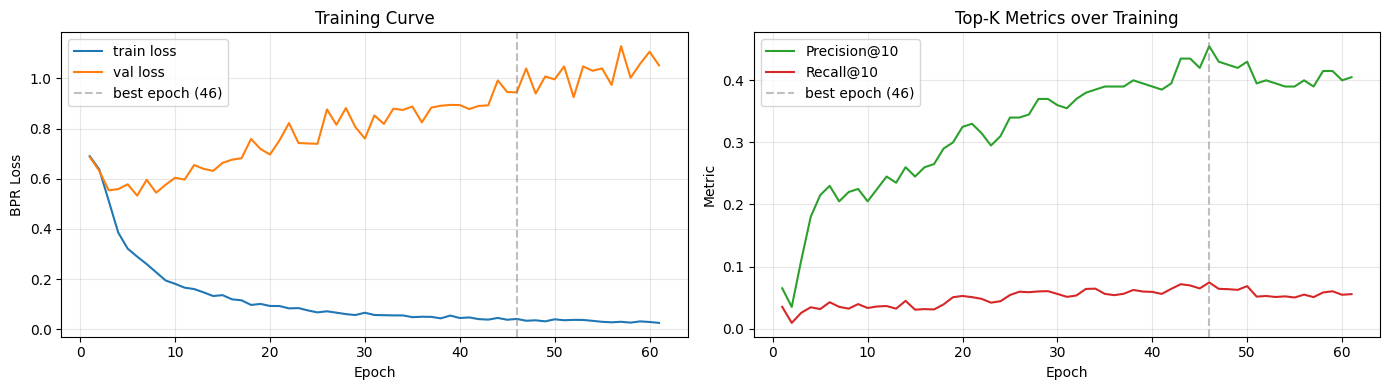

In [ ]:
import matplotlib.pyplot as plt

n_completed = len(train_losses)
epochs_x = range(1, n_completed + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#Losses
axes[0].plot(epochs_x, train_losses, label="train loss")
axes[0].plot(epochs_x, val_losses, label="val loss")
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch})')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BPR Loss")
axes[0].set_title("Training Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

#Metrics
axes[1].plot(epochs_x, precisions_at_k, label="Precision@10", color='C2')
axes[1].plot(epochs_x, recalls_at_k, label="Recall@10", color='C3')
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch})')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].set_title("Top-K Metrics over Training")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/loss_curve.png", dpi=120)
plt.show()

## Seventh Step - Evaluation

Precion@10 Recall@10

In [ ]:
model.eval()
with torch.no_grad():
    all_movie_embeddings = model.encode_movie(movie_features_tensor_dev)

train_pos_by_user = defaultdict(set)
for u, m in train_pairs:
    train_pos_by_user[u].add(m)

val_pos_by_user = defaultdict(set)
for u, m in val_pairs:
    val_pos_by_user[u].add(m)

per_user_metrics = []
with torch.no_grad():
    for u_id in range(n_users):
        if not val_pos_by_user[u_id]:
            continue

        u_emb = model.encode_user(torch.tensor([u_id], device=device))
        scores = (u_emb * all_movie_embeddings).sum(dim=1)


        excluded = seen_by_user[u_id] - val_pos_by_user[u_id]
        if excluded:
            scores[list(excluded)] = -1e9

        topk = torch.topk(scores, k=TOP_K).indices.cpu().tolist()
        relevant = val_pos_by_user[u_id]
        hits = len(set(topk) & relevant)
        precision = hits / TOP_K
        recall = hits / len(relevant)
        per_user_metrics.append({
            "username": id2user[u_id],
            "n_val_positives": len(relevant),
            "hits": hits,
            "precision_at_k": precision,
            "recall_at_k": recall,
        })

metrics_df = pd.DataFrame(per_user_metrics)
print("User Metrics:\n")
print(metrics_df.to_string(index=False))

precision_at_k = metrics_df["precision_at_k"].mean() if len(metrics_df) else 0.0
recall_at_k    = metrics_df["recall_at_k"].mean() if len(metrics_df) else 0.0
print(f"Precision@{TOP_K}: {precision_at_k:.4f}")
print(f"Recall@{TOP_K}:    {recall_at_k:.4f}")
print(f"Evaluated users: {len(metrics_df)}/{n_users}")

User Metrics:

     username  n_val_positives  hits  precision_at_k  recall_at_k
        UserA               75     9             0.9     0.120000
        UserB               60     9             0.9     0.150000
    aaronmbtw               12     0             0.0     0.000000
       alexja               91    10             1.0     0.109890
      amestoy               18     3             0.3     0.166667
    danidc938               22     1             0.1     0.045455
    ddaniel4u               70     9             0.9     0.128571
 fat_capybara              113    10             1.0     0.088496
 isanieto1312               12     0             0.0     0.000000
     jerayrey               10     1             0.1     0.100000
        julez              189    10             1.0     0.052910
 laslegumbres              116     8             0.8     0.068966
  lukwhoshere                9     1             0.1     0.111111
mariathehater               28     1             0.1     0.03

## Eight Step - Saving and Exporting the model

In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "n_users": n_users,
    "movie_feature_dim": movie_feature_dim,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "user2id": user2id,
    "id2user": id2user,
    "movie2id": movie2id,
    "id2movie": id2movie,
    "genre2idx": genre2id,
    "nanogenre2idx": nanogenre2idx,
    "theme2idx": theme2id,
    "movie_features": movie_features_tensor.cpu().numpy(),
    "metrics": {
        "precision_at_k": precision_at_k,
        "recall_at_k":    recall_at_k,
        "top_k":          TOP_K,
        "final_train_loss": train_losses[-1],
        "final_val_loss":   val_losses[-1],
        "per_user": per_user_metrics,
    },
    "positive_threshold": POSITIVE_THRESHOLD,
    "n_epochs":           N_EPOCHS,
    "seed":               SEED,
    "split_strategy":     "temporal",
    "version":            "v3",
}

torch.save(checkpoint, CHECKPOINT_PATH)

from google.colab import files
files.download(CHECKPOINT_PATH)
files.download("/content/loss_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>